## **BAB 7. PENGANTAR NATURAL LANGUAGE PROCESSING (NLP)**

Proses **tokenisasi** adalah langkah fundamental dalam Natural Language Processing (NLP) yang melibatkan pemisahan teks menjadi unit-unit yang lebih kecil, yang disebut token. Token ini bisa berupa kata, frasa, simbol, atau unit-unit bermakna lainnya.

Dalam notebook ini, kita akan mengeksplorasi berbagai metode tokenisasi dalam Bahasa Indonesia:

1.  **Sentence Tokenization**: Memisahkan teks menjadi kalimat-kalimat.
2.  **Word Tokenization Sederhana (Split)**: Menggunakan metode split standar Python.
3.  **Word Tokenization dengan Regex**: Menggunakan ekspresi reguler untuk menangani tanda baca.
4.  **Word Tokenization dengan NLTK**: Memanfaatkan pustaka NLTK yang populer untuk tokenisasi.
5.  **Custom Tokenizer untuk Bahasa Indonesia**: Membuat fungsi tokenisasi khusus yang dirancang untuk menangani karakteristik unik teks Bahasa Indonesia.

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

# Unduh resource NLTK (cukup sekali)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Contoh teks ulasan produk Bahasa Indonesia ──
teks = ('Produk ini sangat bagus! Pengiriman cepat dan packaging aman. '
        'Harganya worth it banget, recommended buat temen-temen. '
        'Seller responsif, fast respon. Bintang 5!')

# ── 1. Sentence tokenization ──
kalimat = sent_tokenize(teks)
print(f'Jumlah kalimat: {len(kalimat)}')
for i, k in enumerate(kalimat, 1):
    print(f'  K{i}: {k}')

# ── 2. Word tokenization sederhana (split) ──
token_split = teks.split()
print(f'\nToken (split): {len(token_split)} token')

# ── 3. Word tokenization dengan regex (menangani tanda baca) ──
pola_token = r'\b\w+\b'
token_regex = re.findall(pola_token, teks.lower())
print(f'Token (regex): {len(token_regex)} token')
print(f'Contoh: {token_regex[:10]}')

# ── 4. Word tokenization dengan NLTK ──
token_nltk = word_tokenize(teks)
print(f'\nToken (NLTK): {len(token_nltk)} token')
print(f'Contoh: {token_nltk[:10]}')

# ── 5. Custom tokenizer untuk Bahasa Indonesia ──
def tokenisasi_id(teks, pertahankan_angka=True):
    """Tokenisasi yang menangani karakteristik teks Indonesia."""
    # Lowercase
    teks = teks.lower()
    # Pisahkan kata gabungan umum: 'temen-temen' → 'temen temen'
    teks = re.sub(r'(\w+)-(\w+)', r'\1 \2', teks)
    # Pertahankan angka jika diperlukan
    if pertahankan_angka:
        pola = r'[a-zA-Z0-9]+(?:[a-zA-Z0-9])*'
    else:
        pola = r'[a-zA-Z]+'
    return re.findall(pola, teks)

token_id = tokenisasi_id(teks)
print(f'\nToken (Custom ID): {len(token_id)}')
print(f'Contoh: {token_id[:12]}')


Jumlah kalimat: 5
  K1: Produk ini sangat bagus!
  K2: Pengiriman cepat dan packaging aman.
  K3: Harganya worth it banget, recommended buat temen-temen.
  K4: Seller responsif, fast respon.
  K5: Bintang 5!

Token (split): 22 token
Token (regex): 23 token
Contoh: ['produk', 'ini', 'sangat', 'bagus', 'pengiriman', 'cepat', 'dan', 'packaging', 'aman', 'harganya']

Token (NLTK): 29 token
Contoh: ['Produk', 'ini', 'sangat', 'bagus', '!', 'Pengiriman', 'cepat', 'dan', 'packaging', 'aman']

Token (Custom ID): 23
Contoh: ['produk', 'ini', 'sangat', 'bagus', 'pengiriman', 'cepat', 'dan', 'packaging', 'aman', 'harganya', 'worth', 'it']


Setelah tokenisasi, langkah penting berikutnya dalam persiapan teks untuk analisis adalah **normalisasi**. Normalisasi melibatkan serangkaian proses untuk mengubah teks menjadi bentuk standar, yang membantu mengurangi variasi data dan meningkatkan kualitas analisis.

Fungsi `normalisasi_teks_id` di bawah ini menyediakan *pipeline* normalisasi yang komprehensif dan dapat dikonfigurasi, meliputi:

*   **Normalisasi Unicode**: Menangani karakter dengan aksen atau bentuk khusus.
*   **Penghapusan URL, Mention, dan Hashtag**: Membersihkan elemen-elemen yang mungkin tidak relevan untuk analisis.
*   **Lowercase**: Mengubah semua teks menjadi huruf kecil untuk perlakuan yang seragam.
*   **Penghapusan Angka dan Tanda Baca**: Membersihkan karakter non-alfabetik atau numerik yang tidak diinginkan.
*   **Penghapusan Spasi Ganda**: Memastikan konsistensi spasi.

In [ ]:
import re
import unicodedata

def normalisasi_teks_id(teks, config=None):
    """
    Pipeline normalisasi teks Bahasa Indonesia yang dapat dikonfigurasi.

    config: dict dengan opsi:
        lowercase (bool): ubah ke huruf kecil [default: True]
        hapus_url (bool): hapus URL [default: True]
        hapus_mention (bool): hapus @mention [default: True]
        hapus_hashtag (bool): hapus #hashtag [default: False]
        hapus_angka (bool): hapus semua angka [default: False]
        hapus_tanda_baca (bool): hapus tanda baca [default: True]
        normalisasi_unicode (bool): NFKC normalization [default: True]
        hapus_spasi_ganda (bool): hapus whitespace ganda [default: True]
    """
    if config is None:
        config = {}

    # Default configuration
    cfg = {
        'lowercase'           : True,
        'hapus_url'           : True,
        'hapus_mention'       : True,
        'hapus_hashtag'       : False,  # Hashtag bisa informatif
        'hapus_angka'         : False,
        'hapus_tanda_baca'    : True,
        'normalisasi_unicode' : True,
        'hapus_spasi_ganda'   : True,
    }
    cfg.update(config)

    # 1. Normalisasi Unicode (menangani karakter aksen dan special chars)
    if cfg['normalisasi_unicode']:
        teks = unicodedata.normalize('NFKC', teks)

    # 2. Hapus URL (http://, https://, www.)
    if cfg['hapus_url']:
        teks = re.sub(r'https?://\S+|www\.\S+', '', teks)

    # 3. Hapus @mention
    if cfg['hapus_mention']:
        teks = re.sub(r'@\w+', '', teks)

    # 4. Tangani hashtag
    if cfg['hapus_hashtag']:
        teks = re.sub(r'#\w+', '', teks)
    else:
        teks = re.sub(r'#(\w+)', r'\1', teks)  # Hapus # tapi pertahankan kata

    # 5. Lowercase
    if cfg['lowercase']:
        teks = teks.lower()

    # 6. Hapus angka (opsional)
    if cfg['hapus_angka']:
        teks = re.sub(r'\d+', '', teks)

    # 7. Hapus tanda baca dan karakter non-alfanumerik
    if cfg['hapus_tanda_baca']:
        teks = re.sub(r'[^\w\s]', ' ', teks)

    # 8. Hapus spasi ganda
    if cfg['hapus_spasi_ganda']:
        teks = re.sub(r'\s+', ' ', teks).strip()

    return teks

# ── Contoh penggunaan ──
teks_asli = ('@warihmaharani Produk ini SANGAT bagus!! 😍 '
             'Cek di https://tokopedia.com/toko123 #recommended '
             'Harga Rp 150.000 worth it banget!!')

print('Asli   :', teks_asli)
print('Normal :', normalisasi_teks_id(teks_asli))


Asli   : @warihmaharani Produk ini SANGAT bagus!! 😍 Cek di https://tokopedia.com/toko123 #recommended Harga Rp 150.000 worth it banget!!
Normal : produk ini sangat bagus cek di recommended harga rp 150 000 worth it banget


Setelah tokenisasi dan normalisasi, langkah berikutnya yang sering dilakukan dalam pra-pemrosesan teks adalah penghapusan **stopword**. Stopword adalah kata-kata umum yang sering muncul dalam bahasa (misalnya, 'yang', 'dan', 'di', 'adalah') namun seringkali tidak membawa makna substantif untuk analisis teks. Menghapus stopword dapat membantu mengurangi dimensi data dan meningkatkan efisiensi serta fokus analisis.

Pada bagian ini, kita akan:

*   Mengidentifikasi dan menggabungkan *stopword* dari sumber populer seperti NLTK dan PySastrawi (jika terinstal).
*   Menambahkan *stopword* yang spesifik untuk domain atau gaya bahasa informal.
*   Mengimplementasikan fungsi untuk menghapus *stopword* dari daftar token, dengan opsi untuk mempertahankan kata-kata negasi agar makna kalimat tidak berubah secara drastis.

In [ ]:
# Instal pustaka Sastrawi
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [ ]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)

# ── Stopword Bahasa Indonesia dari NLTK ──
sw_nltk = set(stopwords.words('indonesian'))
print(f'NLTK Indonesian stopwords: {len(sw_nltk)} kata')
print(f'Contoh: {list(sw_nltk)[:10]}')

# ── Stopword tambahan dari PySastrawi ──
try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import (
        StopWordRemoverFactory, ArrayDictionary)

    factory = StopWordRemoverFactory()
    sw_sastrawi = set(factory.get_stop_words())
    print(f'\nSastrawi stopwords: {len(sw_sastrawi)} kata')
    print(f'Contoh: {list(sw_sastrawi)[:10]}')

    # Perbandingan Sastrawi dan NLTK
    print('\n--- Perbandingan Stopword NLTK vs Sastrawi ---')
    print(f'Jumlah stopword di NLTK: {len(sw_nltk)}')
    print(f'Jumlah stopword di Sastrawi: {len(sw_sastrawi)}')
    print(f'Jumlah stopword bersama (intersection): {len(sw_nltk.intersection(sw_sastrawi))}')
    print(f'Stopword unik di NLTK: {len(sw_nltk - sw_sastrawi)} kata. Contoh: {list(sw_nltk - sw_sastrawi)[:5]}')
    print(f'Stopword unik di Sastrawi: {len(sw_sastrawi - sw_nltk)} kata. Contoh: {list(sw_sastrawi - sw_nltk)[:5]}')


except ModuleNotFoundError:
    print('\nPustaka Sastrawi tidak ditemukan. Menggunakan stopword NLTK saja.')
    sw_sastrawi = set()

# ── Gabungkan dan tambahkan stopword domain-spesifik ──
sw_domain = {'yg', 'dgn', 'utk', 'jg', 'sdh', 'blm', 'krn',  # Singkatan umum
             'kak', 'bang', 'mas', 'bu', 'pak',               # Sapaan
             'nih', 'tuh', 'deh', 'dong', 'sih', 'loh', 'kan'} # Partikel informal

sw_lengkap = sw_nltk | sw_sastrawi | sw_domain
print(f'\nStopword gabungan: {len(sw_lengkap)} kata')

# ── Fungsi penghapusan stopword ──
def hapus_stopword(token_list, stopword_set, negasi_pertahankan=True):
    """
    Menghapus stopword dari daftar token.
    negasi_pertahankan: pertahankan kata negasi ('tidak', 'bukan', 'jangan')
    """
    KATA_NEGASI = {'tidak', 'bukan', 'jangan', 'belum', 'tanpa',
                   'tiada', 'tak', 'non', 'anti'}
    hasil = []
    for token in token_list:
        if negasi_pertahankan and token in KATA_NEGASI:
            hasil.append(token)  # Pertahankan kata negasi
        elif token not in stopword_set:
            hasil.append(token)
    return hasil

# Demo
token_contoh = ['produk', 'ini', 'tidak', 'bagus', 'dan', 'harga',
                'sangat', 'mahal', 'untuk', 'kualitas', 'yang', 'diberikan']
token_bersih = hapus_stopword(token_contoh, sw_lengkap)
print(f'\nSebelum: {token_contoh}')
print(f'Sesudah : {token_bersih}')

NLTK Indonesian stopwords: 757 kata
Contoh: ['ingat', 'disebutkan', 'naik', 'lagi', 'kelamaan', 'diberi', 'berlebihan', 'diperbuatnya', 'ialah', 'menunjukkan']

Sastrawi stopwords: 123 kata
Contoh: ['pun', 'apakah', 'dahulu', 'lagi', 'anda', 'dua', 'itu', 'harus', 'kepada', 'seharusnya']

--- Perbandingan Stopword NLTK vs Sastrawi ---
Jumlah stopword di NLTK: 757
Jumlah stopword di Sastrawi: 123
Jumlah stopword bersama (intersection): 106
Stopword unik di NLTK: 651 kata. Contoh: ['ingat', 'disebutkan', 'naik', 'kelamaan', 'diberi']
Stopword unik di Sastrawi: 17 kata. Contoh: ['kah', 'dsb', 'oh', 'tolong', 'kecuali']

Stopword gabungan: 790 kata

Sebelum: ['produk', 'ini', 'tidak', 'bagus', 'dan', 'harga', 'sangat', 'mahal', 'untuk', 'kualitas', 'yang', 'diberikan']
Sesudah : ['produk', 'tidak', 'bagus', 'harga', 'mahal', 'kualitas']


Langkah pra-pemrosesan teks penting lainnya adalah **stemming**. Stemming adalah proses mengurangi kata-kata berafiks (berimbuhan) menjadi bentuk dasar atau akar kata (stem) mereka. Tujuannya adalah untuk mengelompokkan kata-kata yang memiliki makna serupa tetapi berbeda dalam bentuknya (misalnya, 'menulis', 'ditulis', 'penulisan' semuanya direduksi menjadi 'tulis').

Pada bagian ini, kita akan menggunakan pustaka **PySastrawi** untuk melakukan *stemming* Bahasa Indonesia. PySastrawi merupakan salah satu implementasi *stemmer* Bahasa Indonesia yang cukup komprehensif. Kita akan melihat bagaimana kata-kata dengan berbagai imbuhan direduksi ke bentuk dasarnya dan mengaplikasikannya pada contoh kalimat.

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# ── Inisialisasi stemmer PySastrawi ──
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# ── Demonstrasi stemming ──
contoh_kata = [
    'menulis', 'ditulis', 'penulisan', 'penulis', 'tulisan',
    'berlari', 'lari', 'pelari', 'berlarian', 'melari',
    'mempercantik', 'kecantikan', 'cantik', 'memperindah',
    'ketidaksesuaian', 'penghapusan', 'diimplementasikan',
]

print(f'{'Kata Asli':<25} {'Stem':>15}')
print('-' * 42)
for kata in contoh_kata:
    stem = stemmer.stem(kata)
    sama = '✓' if stem == kata else ''
    print(f'{kata:<25} {stem:>15} {sama}')

# ── Fungsi stemming untuk daftar token ──
def stem_tokens(token_list, stemmer):
    return [stemmer.stem(t) for t in token_list]

# ── Contoh pada kalimat ──
kalimat_test = 'penghapusan data dilakukan untuk menjaga keamanan sistem'
token_test = kalimat_test.split()
token_stem = stem_tokens(token_test, stemmer)
print(f'\nAsli   : {token_test}')
print(f'Stem   : {token_stem}')


Kata Asli                            Stem
------------------------------------------
menulis                             tulis 
ditulis                             tulis 
penulisan                           tulis 
penulis                             tulis 
tulisan                             tulis 
berlari                              lari 
lari                                 lari ✓
pelari                               lari 
berlarian                            lari 
melari                               lari 
mempercantik                       cantik 
kecantikan                         cantik 
cantik                             cantik ✓
memperindah                         indah 
ketidaksesuaian           ketidaksesuaian ✓
penghapusan                         hapus 
diimplementasikan            implementasi 

Asli   : ['penghapusan', 'data', 'dilakukan', 'untuk', 'menjaga', 'keamanan', 'sistem']
Stem   : ['hapus', 'data', 'laku', 'untuk', 'jaga', 'aman', 'sistem']


Teks Bahasa Indonesia, terutama di media sosial dan ulasan produk, seringkali memiliki karakteristik unik seperti penggunaan **campur kode** (code-mixing) dan kata-kata tidak baku atau slang. Campur kode dapat melibatkan pencampuran Bahasa Indonesia dengan bahasa asing (terutama Inggris), bahasa gaul, atau bahkan bahasa daerah. Kata-kata tidak baku dan singkatan juga sangat umum.

Untuk memastikan bahwa proses NLP berikutnya dapat bekerja secara efektif, penting untuk menormalisasi teks ini ke bentuk yang lebih standar dan formal. Pada bagian ini, kita akan:

*   Mengidentifikasi contoh-contoh umum campur kode dan kata tidak baku.
*   Membuat kamus (`KAMUS_NORMALISASI`) untuk memetakan kata-kata tidak baku, singkatan, dan serapan umum ke padanan formalnya.
*   Mengimplementasikan fungsi `normalisasi_kata_tidak_baku` yang menggunakan kamus ini untuk mengganti token-token dalam teks.

In [ ]:
# Contoh teks dengan campur kode yang umum di media sosial Indonesia
contoh_campur_kode = [
    # Indonesia + Inggris (paling umum)
    'Produknya bagus banget, fast respon sellernya, recommended!',
    'Meeting-nya cancel, jadi bisa WFH hari ini, happy banget!',

    # Indonesia + bahasa gaul
    'Udah cobain belum? Worth it banget sumpah, ga nyesel deh beli',
    'Emang bener kata temen gue, packaging-nya kece abis',

    # Indonesia + bahasa daerah (Jawa, Sunda, dll.)
    'Produke apik tenan, pokoke recommended!',     # campur Jawa
    'Alus pisan barangna, hargana oge murah',      # campur Sunda

    # Singkatan dan akronim khas Indonesia
    'Ongkir gratis buat pembelian min 100rb, free ongkos kirim lho',
    'Sdh beli 3x, seller terpercaya, tq kak fast respon',
]

# Tantangan: kata 'ga' (tidak), 'udah' (sudah), 'banget' (sangat)
# perlu dipetakan ke padanan formal sebelum NLP

# ── Kamus normalisasi kata tidak baku → baku ──
KAMUS_NORMALISASI = {
    # Kata gaul umum
    'ga'    : 'tidak',  'gak'   : 'tidak',  'nggak' : 'tidak',
    'udah'  : 'sudah',  'udh'   : 'sudah',  'dah'   : 'sudah',
    'tapi'  : 'tetapi', 'tp'    : 'tetapi',
    'kalo'  : 'kalau',  'klo'   : 'kalau',
    'banget': 'sangat', 'bgt'   : 'sangat',
    'emang' : 'memang', 'beneran': 'benar', 'bener' : 'benar',
    'gimana': 'bagaimana', 'gmn' : 'bagaimana',
    'sampe' : 'sampai', 'ampe'  : 'sampai',
    # Singkatan umum
    'yg'    : 'yang',   'dgn'   : 'dengan', 'utk'   : 'untuk',
    'jg'    : 'juga',   'blm'   : 'belum',  'sdh'   : 'sudah',
    'krn'   : 'karena', 'tdk'   : 'tidak',  'pd'    : 'pada',
    'thx'   : 'terima kasih', 'tq': 'terima kasih', 'makasih': 'terima kasih',
    # Kata serapan dari Inggris yang umum di e-commerce
    'recommended': 'rekomendasi',
    'packaging'  : 'kemasan',
    'seller'     : 'penjual',
    'fast respon': 'cepat respons',
}

def normalisasi_kata_tidak_baku(token_list, kamus):
    """Mengganti kata tidak baku dengan padanan formal menggunakan kamus."""
    return [kamus.get(t.lower(), t) for t in token_list]


Selain menormalisasi kata tidak baku menggunakan kamus, penting juga untuk menangani **variasi penulisan informal** yang umum terjadi pada teks Bahasa Indonesia, terutama di media sosial. Ini termasuk penulisan berlebihan (misalnya, 'bagusss'), penggunaan emoji, tawa ('wkwkwk'), kata berulang dengan tanda hubung yang tidak standar, serta pemisahan angka dan teks yang salah ('100rb').

Fungsi `tangani_variasi_penulisan` di bawah ini dirancang untuk:

*   **Menormalisasi pengulangan huruf**: Mengurangi pengulangan berlebihan (misalnya, `bagusss` menjadi `bagus`).
*   **Menghapus emoji dan karakter khusus**: Membersihkan teks dari elemen visual yang mungkin tidak relevan.
*   **Normalisasi tawa**: Mengidentifikasi dan mengganti berbagai bentuk tawa (`wkwkwk`, `hahaha`) dengan token standar `<tawa>`.
*   **Menangani kata berulang dengan tanda hubung**: Memisahkan kata-kata yang salah menggunakan tanda hubung.
*   **Memisahkan angka dari kata**: Memastikan angka dan unit di sekitarnya dipisahkan dengan benar (misalnya, `100rb` menjadi `100 rb`).

Langkah ini bertujuan untuk lebih merapikan teks sebelum proses NLP lebih lanjut, menjadikannya lebih konsisten dan mudah diproses.

In [ ]:
import re

def tangani_variasi_penulisan(teks):
    """Menormalisasi variasi penulisan umum dalam teks Indonesia informal."""

    # 1. Normalisasi pengulangan huruf ('bagusss' → 'bagus')
    # Pertahankan maksimal 2 karakter berulang untuk menghindari
    # over-normalisasi ('tapi' bukan 'tapii')
    teks = re.sub(r'(.)\1{2,}', r'\1\1', teks)

    # 2. Hapus emoji dan karakter khusus non-alfanumerik
    # Gunakan range Unicode untuk emoji
    emoji_pola = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    teks = emoji_pola.sub(' ', teks)

    # 3. Normalisasi tawa ('wkwkwk', 'hahaha', 'xixi') → '<tawa>'
    teks = re.sub(r'\b(wk){2,}\b', '<tawa>', teks, flags=re.IGNORECASE)
    teks = re.sub(r'\b(ha){2,}\b', '<tawa>', teks, flags=re.IGNORECASE)
    teks = re.sub(r'\b(hi){2,}\b', '<tawa>', teks, flags=re.IGNORECASE)

    # 4. Tangani kata dengan tanda penghubung (reduplikasi)
    # 'teman-teman' → pertahankan apa adanya (akan ditangani stemmer)
    # Tapi 'no-way' (Inggris) → 'no way'
    teks = re.sub(r'(?<=[a-z])-(?=[a-z])', ' ', teks)

    # 5. Pisahkan angka dari kata ('100rb' → '100 rb', '5jt' → '5 jt')
    teks = re.sub(r'(\d+)([a-zA-Z])', r'\1 \2', teks)
    teks = re.sub(r'([a-zA-Z])(\d+)', r'\1 \2', teks)

    return teks.strip()

# Demonstrasi
contoh = ['Bagusssss banget!!! 😍😍 wkwkwk', 'harganya 100rb doang']
for c in contoh:
    print(f'Asli  : {c}')
    print(f'Normal: {tangani_variasi_penulisan(c)}')
    print()


Asli  : Bagusssss banget!!! 😍😍 wkwkwk
Normal: Baguss banget!!    <tawa>

Asli  : harganya 100rb doang
Normal: harganya 100 rb doang



Setelah teks melalui berbagai tahapan pra-pemrosesan seperti tokenisasi, normalisasi, penghapusan *stopword*, *stemming*, dan penanganan variasi penulisan informal, langkah berikutnya dalam banyak tugas NLP adalah merepresentasikan teks tersebut dalam format numerik yang dapat dipahami oleh algoritma *machine learning*.

Dua metode representasi vektor teks yang paling dasar dan umum adalah:

1.  **Bag-of-Words (BoW)**: Model ini merepresentasikan teks sebagai kantung (multiset) kata-kata, mengabaikan tata bahasa dan urutan kata, tetapi tetap memperhatikan frekuensi kemunculan setiap kata dalam dokumen. BoW menciptakan matriks di mana setiap baris mewakili dokumen dan setiap kolom mewakili kata unik dari seluruh korpus, dengan nilai sel menunjukkan frekuensi kata tersebut dalam dokumen.

2.  **N-gram**: Untuk mengatasi keterbatasan BoW yang mengabaikan urutan kata, *N-gram* digunakan. *N-gram* adalah urutan *N* item yang berdekatan dari sampel teks atau ucapan. Misalnya, *bigram* (2-gram) adalah pasangan kata yang berurutan, dan *trigram* (3-gram) adalah tiga kata berurutan. Dengan menggunakan *N-gram*, kita dapat menangkap konteks lokal dan frasa yang lebih bermakna.

Pada bagian ini, kita akan menggunakan `CountVectorizer` dari pustaka `scikit-learn` untuk mengimplementasikan kedua metode ini, serta melihat bagaimana outputnya disajikan.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# ── Dataset contoh: ulasan produk yang sudah dipra-proses ──
ulasan = [
    'produk bagus harga murah bagus',
    'produk jelek harga mahal kualitas buruk',
    'harga sesuai kualitas produk mantap',
    'produk rusak pengiriman lama kecewa',
    'kemasan rapi produk bagus harga terjangkau',
]
label = ['positif', 'negatif', 'positif', 'negatif', 'positif']

# ── CountVectorizer: konfigurasi dasar ──
cv = CountVectorizer(
    max_features = None,    # Gunakan semua kata
    min_df       = 1,       # Kata harus muncul minimal di 1 dokumen
    max_df       = 1.0,     # Abaikan kata yang muncul di >100% dokumen
    ngram_range  = (1, 1),  # Hanya unigram (kata tunggal)
    binary       = False,   # Gunakan frekuensi, bukan 0/1
)

# Fit dan transform
X_bow = cv.fit_transform(ulasan)

# Hasil dalam bentuk sparse matrix
print(f'Dimensi matriks BoW : {X_bow.shape}')
print(f'Kosakata ({len(cv.vocabulary_)} kata): {sorted(cv.vocabulary_.keys())}')

# Tampilkan sebagai DataFrame untuk interpretasi
df_bow = pd.DataFrame(
    X_bow.toarray(),
    columns=cv.get_feature_names_out(),
    index=[f'D{i+1}' for i in range(len(ulasan))]
)
print('\nMatriks BoW:')
print(df_bow.to_string())

# ── N-gram: menangkap frasa ──
cv_bigram = CountVectorizer(ngram_range=(1, 2), max_features=20)
X_bigram = cv_bigram.fit_transform(ulasan)
print(f'\nFitur bigram (top 20): {cv_bigram.get_feature_names_out()}')


Dimensi matriks BoW : (5, 17)
Kosakata (17 kata): ['bagus', 'buruk', 'harga', 'jelek', 'kecewa', 'kemasan', 'kualitas', 'lama', 'mahal', 'mantap', 'murah', 'pengiriman', 'produk', 'rapi', 'rusak', 'sesuai', 'terjangkau']

Matriks BoW:
    bagus  buruk  harga  jelek  kecewa  kemasan  kualitas  lama  mahal  mantap  murah  pengiriman  produk  rapi  rusak  sesuai  terjangkau
D1      2      0      1      0       0        0         0     0      0       0      1           0       1     0      0       0           0
D2      0      1      1      1       0        0         1     0      1       0      0           0       1     0      0       0           0
D3      0      0      1      0       0        0         1     0      0       1      0           0       1     0      0       1           0
D4      0      0      0      0       1        0         0     1      0       0      0           1       1     0      1       0           0
D5      1      0      1      0       0        1         0     0      0

Dimensi matriks TF-IDF: (6, 6)
Kosakata: 6 kata unik


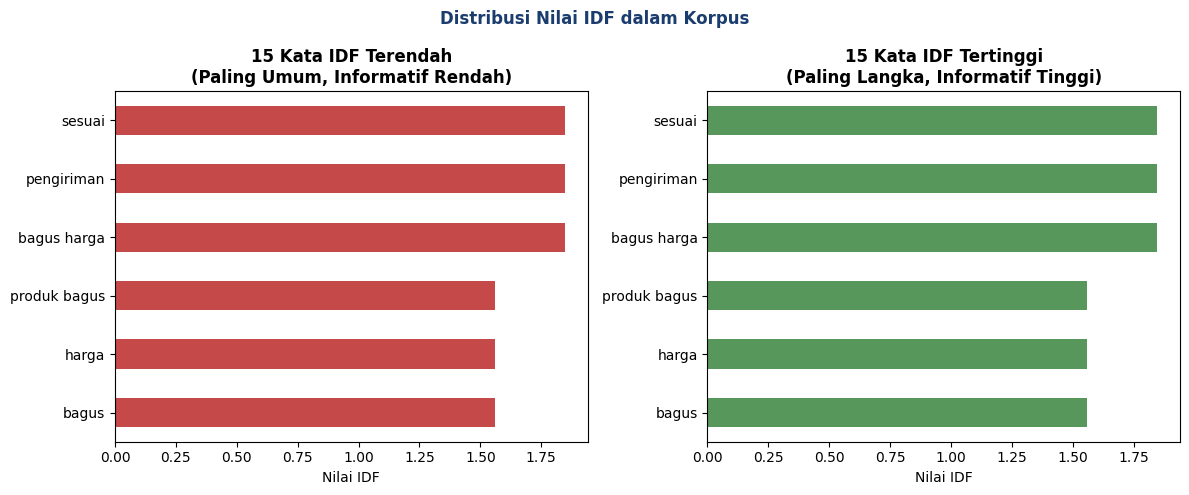

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import os # Import the os module

# Asumsikan 'ulasan' didefinisikan di sel sebelumnya (misal dari bagian BoW)
# Jika tidak, Anda bisa mendefinisikannya di sini, misalnya:
ulasan = [
    'produk bagus harga murah bagus',
    'produk jelek harga mahal kualitas buruk',
    'harga sesuai kualitas produk mantap',
    'produk rusak pengiriman lama kecewa',
    'kemasan rapi produk bagus harga terjangkau',
    'harga murah tapi kualitas bagus',
    'pengiriman cepat produk bagus banget',
    'produk jelek tidak sesuai gambar'
]

# Bagi data menjadi training dan testing
ulasan_train, ulasan_test = train_test_split(ulasan, test_size=0.2, random_state=42)

# ── TF-IDF dasar ──
tfidf = TfidfVectorizer(
    max_features = 1000,    # Batasi ke 1000 fitur teratas
    min_df       = 2,       # Abaikan kata yang muncul < 2 dokumen
    max_df       = 0.95,    # Abaikan kata yang muncul di > 95% dokumen
    ngram_range  = (1, 2),  # Unigram + bigram
    sublinear_tf = True,    # Gunakan 1+log(TF) alih-alih TF mentah
    smooth_idf    = True,    # Tambah 1 pada IDF untuk stabilitas
    norm         = 'l2',    # Normalisasi L2 tiap vektor dokumen
)

# Fit pada data latih SAJA, transform untuk latih dan uji
X_train_tfidf = tfidf.fit_transform(ulasan_train)
X_test_tfidf  = tfidf.transform(ulasan_test)

print(f'Dimensi matriks TF-IDF: {X_train_tfidf.shape}')
print(f'Kosakata: {len(tfidf.vocabulary_)} kata unik')

# ── Inspeksi skor TF-IDF per dokumen ──
def top_tfidf_kata(tfidf_model, X_tfidf, idx_dokumen, top_n=10):
    """Menampilkan kata dengan skor TF-IDF tertinggi untuk satu dokumen."""
    fitur = tfidf_model.get_feature_names_out()
    skor  = X_tfidf[idx_dokumen].toarray().ravel()
    df_skor = pd.DataFrame({'kata': fitur, 'tfidf': skor})
    df_skor = df_skor[df_skor['tfidf'] > 0].sort_values('tfidf', ascending=False)
    return df_skor.head(top_n)

# Tampilkan kata paling diskriminatif pada dokumen pertama
# print(top_tfidf_kata(tfidf, X_train_tfidf, idx_dokumen=0))

# ── Visualisasi IDF: kata dengan IDF tertinggi dan terendah ──
idf_series = pd.Series(
    tfidf.idf_, index=tfidf.get_feature_names_out()
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Kata dengan IDF terendah (paling umum di korpus)
idf_series.head(15).plot(kind='barh', ax=axes[0],
                          color='#B71C1C', alpha=0.8)
axes[0].set_title('15 Kata IDF Terendah\n(Paling Umum, Informatif Rendah)',
                   fontweight='bold')
axes[0].set_xlabel('Nilai IDF')

# Kata dengan IDF tertinggi (paling langka, paling informatif)
idf_series.tail(15).sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='#2E7D32', alpha=0.8
)
axes[1].set_title('15 Kata IDF Tertinggi\n(Paling Langka, Informatif Tinggi)',
                   fontweight='bold')
axes[1].set_xlabel('Nilai IDF')

plt.suptitle('Distribusi Nilai IDF dalam Korpus',
             fontweight='bold', color='#1A3C6E')
plt.tight_layout()

# Membuat direktori 'output' jika belum ada
os.makedirs('output', exist_ok=True)

plt.savefig('output/idf_distribusi.pdf', bbox_inches='tight')
plt.show()